# Plots & Tables

In [1]:
import json
from pathlib import Path

import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append("..")
from world.world import World

labels_mapping = {
    "pre-trained": "Pre-Trained Model",
    "DC": "Direct Counting",
    "PtC": "Point-then-Count",
    "x-ft-balanced": "X Fine-tuning",
    "pointing-default-balanced": "Base Model + Pointing",
}

model_mapping = {
    "molmo-o-7b": "Molmo-O-7B",
    "qwen2.5-vl-7b": "Qwen2.5-VL-7B",
    "qwen2.5-vl-3b": "Qwen2.5-VL-3B",
    "llava-onevision-8b": "LLaVA OneVision 8B",
    "internvl3_5-8b": "InternVL3 5-8B",
}

markers = {
    "pre-trained": "o", 
    "DC": "s",
    "PtC": "D",
    "pointing-default-balanced": "^",
    "x-ft-balanced": "X",
}

linestyles = {
    "pre-trained": "-",
    "DC": "--",
    "PtC": "-.",
    "pointing-default-balanced": ":",
    "x-ft-balanced": "-",
}

colors = {    
    "pre-trained": "#1f77b4",  # blue
    "DC": "#d95f02",  # orange
    "PtC": "#1b9e77",  # green
    "x-ft-balanced": "#e7298a", # pink
}

models = {
    "molmo-o-7b": "Molmo-O-7B",
    "qwen2.5-vl-7b": "Qwen2.5-VL 7B",
    "qwen2.5-vl-3b": "Qwen2.5-VL 3B",
    "llava-onevision-8b": "LLaVA OneVision 8B",
    "internvl3_5-8b": "InternVL3.5 8B",
}

model_names = list(m for m in models.keys() if "molmo" not in m)


## ID

### Counting Accuracy per Object

In [2]:
output_dir = Path("../output")

results = []

for experiment_name in [
    "DC/id",
    "PtC/id",
]:
    for model_name in [
        "qwen2.5-vl-3b",
        "qwen2.5-vl-7b",
        "llava-onevision-8b",
        "internvl3_5-8b",
        #"molmo-o-7b",
    ]:
        if not (output_dir / model_name / experiment_name / "summary.json").exists():
            continue
        with open(
            output_dir / model_name / experiment_name / "summary.json"
        ) as f:
            report = json.load(f)

        for target_object, acc in report.items():
            results.append(
                {
                    "Model": model_mapping.get(model_name, model_name),
                    "Experiment": labels_mapping.get(experiment_name, experiment_name),
                    "Number of Target Objects": target_object,
                    "Accuracy": acc["accuracy"],
                }
            )

#### Average among PtC and DC

In [3]:
# AVERAGE

df = pd.DataFrame(results)
# Group by target object and compute mean accuracy across both methods
grouped_df = df.groupby('Number of Target Objects')['Accuracy'].agg(['mean', 'std']).reset_index()
grouped_df.columns = ['Number of Target Objects', 'Average Accuracy', 'Std']
grouped_df = grouped_df.sort_values('Average Accuracy', ascending=False)
grouped_df

,Number of Target Objects,Average Accuracy,Std
2,blue_stars,0.997942,0.002200
0,blue_circles,0.997771,0.004208
14,magenta_stars,0.996571,0.004637
4,cyan_circles,0.996399,0.005335
18,red_stars,0.996228,0.005172
6,cyan_stars,0.996056,0.009053
12,magenta_circles,0.995542,0.006670
10,green_stars,0.994684,0.011946
20,yellow_circles,0.994513,0.006640
8,green_circles,0.994513,0.009099


#### Single approach

In [4]:
df = pd.DataFrame(results)
# Filter for one of the two approaches
#single_approach_df = df[df['Experiment'] == 'Direct Counting']
single_approach_df = df[df['Experiment'] == 'Point-then-Count']

# Group by target object and compute mean accuracy across models
grouped_df = single_approach_df.groupby('Number of Target Objects')['Accuracy'].agg(['mean', 'std']).reset_index()
grouped_df.columns = ['Number of Target Objects', 'Average Accuracy', 'Std']
grouped_df = grouped_df.sort_values('Average Accuracy', ascending=False)
grouped_df


,Number of Target Objects,Average Accuracy,Std


### Plot Avg across models

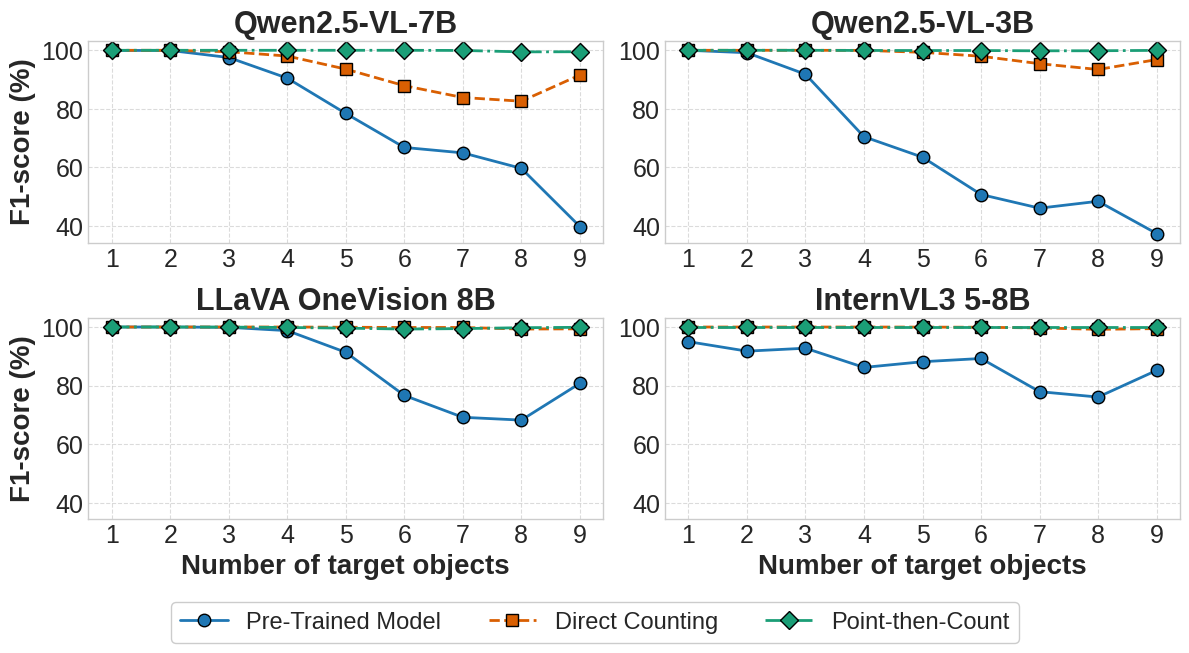

In [5]:
output_dir = Path("../output")
results = {}

for model_name in model_names:
    results[model_name] = {}
    for experiment_name in [
        "pre-trained/id",
        "DC/id",
        "PtC/id"
    ]:
        if not (output_dir / model_name / experiment_name / "classification_report.json").exists():
            continue
        with open(
            output_dir / model_name / experiment_name / "classification_report.json"
        ) as f:
            report = json.load(f)

        if experiment_name not in results[model_name]:
            results[model_name][experiment_name] = {}
        for key, value in report.items():
            if key.isdigit():
                if int(key) not in results[model_name][experiment_name]:
                    results[model_name][experiment_name][int(key)] = value["f1-score"] * 100

# plot config
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharey=True)
axes = axes.flatten()

# plot results for each model
for idx, model_name in enumerate(model_names):
    ax = axes[idx]
    
    if "pre-trained/id" in results[model_name]:
        labels = sorted(results[model_name]["pre-trained/id"].keys())
        x = np.arange(len(labels))
        
        for exp_name in ["pre-trained/id", "DC/id", "PtC/id"]:
            if exp_name in results[model_name]:
                y = [results[model_name][exp_name][label] for label in labels]
                exp_name = exp_name.replace("/id", "")
                ax.plot(
                    x,
                    y,
                    marker=markers.get(exp_name, "o"),
                    label=labels_mapping.get(exp_name, exp_name),
                    linestyle=linestyles.get(exp_name, "-"),
                    color=colors.get(exp_name, "black"),
                    linewidth=2,
                    markersize=9,
                    markeredgewidth=1,
                    markeredgecolor="black",
                )
        
        #ax.legend(frameon=True, facecolor="white", fontsize=17, framealpha=1, loc="lower left")
        ax.grid(alpha=0.7, linestyle="--")
        if idx % 2 == 0:
            ax.set_ylabel("F1-score (%)", fontsize=20, fontweight="semibold")
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.tick_params(axis="both", labelsize=18)
        if idx >= 2:
            ax.set_xlabel("Number of target objects", fontsize=20, fontweight="semibold")
        ax.set_title(model_mapping[model_name], fontsize=22, fontweight="bold")
        ax.tick_params(axis='y', which='both', labelleft=True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    frameon=True,
    facecolor="white",
    fontsize=17,
    framealpha=1,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.1),
)

plt.tight_layout()
plt.savefig(
    output_dir / "f1_score_per_number_of_target_objects.pdf",
    bbox_inches="tight",
    dpi=300,
    format='pdf'
)
plt.show()

# Distractors

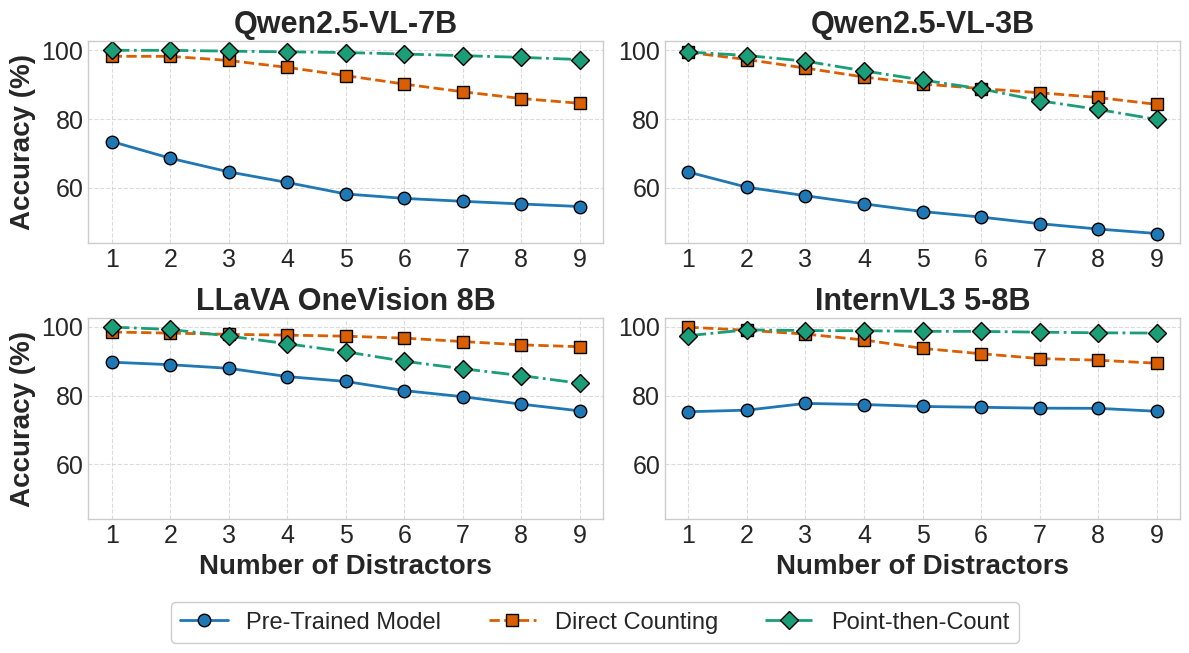

In [6]:
from collections import defaultdict

results = {}
for model_name in model_names:
    for approach_name in ["DC", "PtC"]:
        for n_distractors in range(1, 10):
            fname = f"{n_distractors}_distractors"
            path = output_dir / model_name / approach_name / fname / "classification_report.json"

            with open(path, "r", encoding="utf-8") as f:
                obj = json.load(f)
                acc = obj["accuracy"]
                if model_name not in results:
                    results[model_name] = {}
                if approach_name not in results[model_name]:
                    results[model_name][approach_name] = defaultdict(list)
                results[model_name][approach_name][n_distractors] = [float(acc)*100]
    
    experiment_name = "pre-trained"
    base_model_path = output_dir / model_name / "pre-trained"
    for n_distractors in range(1, 10):
        fname = f"{n_distractors}_distractors"
        path = base_model_path / fname / "classification_report.json"
        if path.exists():
            with open(path, "r", encoding="utf-8") as f:
                obj = json.load(f)
                acc = obj["accuracy"]
                if experiment_name not in results[model_name]:
                    results[model_name][experiment_name] = defaultdict(list)
                results[model_name][experiment_name][n_distractors] = [float(acc)*100]
            


# plotting
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharey=True)
axes = axes.flatten()

for idx, model_name in enumerate(model_names):
    ax = axes[idx]
    
    if model_name not in results:
        continue

    ax.set_title(model_mapping.get(model_name, model_name))
    for exp_name in labels_mapping.keys():
        if exp_name not in results[model_name]:
            continue
        res = results[model_name][exp_name]
        nums = sorted(res.keys())
        accs = [res[n][0] for n in nums]
        x = nums
        y = accs
        ax.plot(
            x,
            y,
            marker=markers.get(exp_name, "o"),
            label=labels_mapping.get(exp_name, exp_name),
            linestyle=linestyles.get(exp_name, "-"),
            color=colors.get(exp_name, "black"),
            linewidth=2,
            markersize=9,
            markeredgewidth=1,
            markeredgecolor="black",
        )
    
    ax.grid(alpha=0.7, linestyle="--")
    if idx % 2 == 0:
        ax.set_ylabel("Accuracy (%)", fontsize=20, fontweight="semibold")
    ax.set_xticks(x)
    ax.tick_params(axis="both", labelsize=18)
    if idx >= 2:
        ax.set_xlabel("Number of Distractors", fontsize=20, fontweight="semibold")
    ax.set_title(model_mapping[model_name], fontsize=22, fontweight="bold")
    ax.tick_params(axis='y', which='both', labelleft=True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    frameon=True,
    facecolor="white",
    fontsize=17,
    framealpha=1,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.1),
)

plt.tight_layout()
plt.savefig(
    output_dir / "distractor_analysis_training_on_distractors.pdf",
    bbox_inches="tight",
    dpi=300,
    format='pdf'
)
plt.show()